# EMA Codebook Update — Visual Experiments

> **Goal:** See the EMA codebook update for what it is — an online k-means that snaps each code to its cluster centroid, independent of the optimizer.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Online k-means** | Does the EMA code actually track the centroid of the points assigned to it as data drifts? |
| 2 | **EMA vs gradient** | How does EMA's convergence compare to SGD on the codebook loss, and does learning rate matter? |
| 3 | **Decay rate γ** | What does turning γ up and down do — smoothness vs lag? |
| 4 | **Laplace smoothing** | Why does a never-selected code blow up, and how does smoothing rescue the division? |

---
**Linked theory:** [research/03-ema-codebook-update.md](../research/03-ema-codebook-update.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


---
## Experiment 1: Online k-means

**Question:** The theory claims a code updated by EMA sits at the centroid of the encoder outputs assigned to it. Does it really track the centroid as the data distribution drifts?

We move a cluster of points along a curve over time and feed mini-batches to the EMA update $N_k \leftarrow \gamma N_k + (1-\gamma)n_k$, $m_k \leftarrow \gamma m_k + (1-\gamma)\sum z_j$, $e_k = m_k/N_k$. The code should chase the running centroid.

In [2]:
np.random.seed(1)

T = 200
gamma = 0.95
true_path = np.stack([np.linspace(-2, 2, T), 1.5 * np.sin(np.linspace(0, 3, T))], axis=1)

N_k = 1.0
m_k = np.array([-2.0, 2.0])   # code starts away from the data
e_path, batch_means = [], []
for t in range(T):
    batch = true_path[t] + 0.3 * np.random.randn(32, 2)   # 32 points around the moving centre
    n = batch.shape[0]
    N_k = gamma * N_k + (1 - gamma) * n
    m_k = gamma * m_k + (1 - gamma) * batch.sum(0)
    e_path.append(m_k / N_k)
    batch_means.append(batch.mean(0))
e_path = np.array(e_path)
batch_means = np.array(batch_means)
print(f'final code {e_path[-1].round(3)}  vs  true centre {true_path[-1].round(3)}')

final code [1.622 0.6  ]  vs  true centre [2.    0.212]


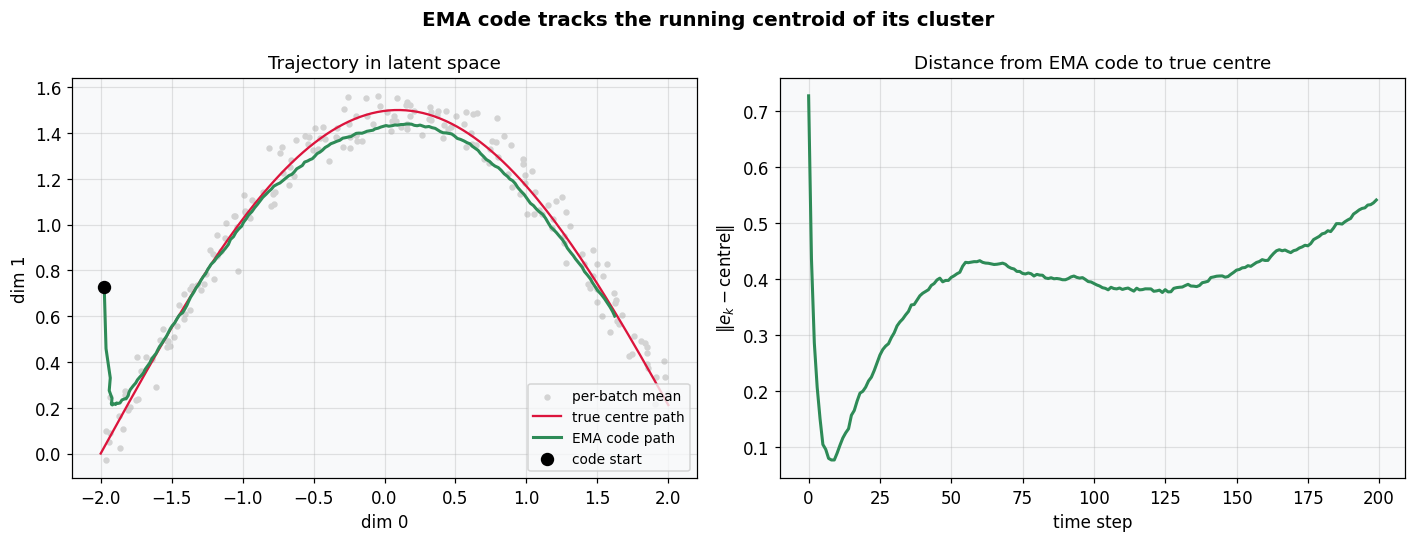

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('EMA code tracks the running centroid of its cluster', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(batch_means[:, 0], batch_means[:, 1], s=10, color='lightgray', label='per-batch mean')
ax.plot(true_path[:, 0], true_path[:, 1], color='crimson', lw=1.5, label='true centre path')
ax.plot(e_path[:, 0], e_path[:, 1], color='seagreen', lw=2, label='EMA code path')
ax.scatter(*e_path[0], color='black', s=60, zorder=5, label='code start')
ax.set_xlabel('dim 0'); ax.set_ylabel('dim 1')
ax.set_title('Trajectory in latent space')
ax.legend(loc='lower right', fontsize=9)

ax2 = axes[1]
err = np.linalg.norm(e_path - true_path, axis=1)
ax2.plot(err, color='seagreen', lw=2)
ax2.set_xlabel('time step'); ax2.set_ylabel('$\\|e_k - \\mathrm{centre}\\|$')
ax2.set_title('Distance from EMA code to true centre')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The green EMA path starts far from the data (black dot, top-left) but quickly catches the red true-centre curve and then rides along just behind it. The right panel confirms it: the distance to the true centre drops fast and then stays small.
2. **Why it looks this way:** $e_k = m_k/N_k$ is a running average of the assigned points, so it converges to their centroid — exactly the k-means update, just computed incrementally. The small residual gap is the EMA lag: it averages over recent batches, so it trails a moving target slightly.
3. **Key takeaway:** EMA is not a heuristic — it is online k-means. Each code parks itself at the centroid of its Voronoi cell's data.

---
## Experiment 2: EMA vs gradient

**Question:** The codebook can instead be moved by SGD on the codebook loss $\lVert \mathrm{sg}[z_e]-e\rVert^2$. How does that compare to EMA, and how sensitive is each to learning rate?

With a fixed cluster, we drive a code to its centroid three ways: EMA, SGD with a small lr, and SGD with a larger lr. EMA should converge fast with no lr to tune; SGD's speed should hinge on the lr.

In [4]:
np.random.seed(2)

centroid = np.array([2.0, -1.0])
data = centroid + 0.4 * np.random.randn(64, 2)
steps = 80
start = np.array([-2.0, 2.0])

# EMA
N_k, m_k = 1.0, start.copy()
ema = [start.copy()]
for _ in range(steps):
    N_k = 0.9 * N_k + 0.1 * len(data)
    m_k = 0.9 * m_k + 0.1 * data.sum(0)
    ema.append(m_k / N_k)
ema = np.array(ema)

# SGD on codebook loss: grad wrt e of mean ||z - e||^2 = -2 (mean(z) - e)
def sgd(lr):
    e = start.copy(); path = [e.copy()]
    for _ in range(steps):
        grad = -2 * (data.mean(0) - e)
        e = e - lr * grad
        path.append(e.copy())
    return np.array(path)

sgd_slow = sgd(0.02)
sgd_fast = sgd(0.2)
to_c = lambda p: np.linalg.norm(p - centroid, axis=1)
print(f'final dist  EMA {to_c(ema)[-1]:.3f} | SGD lr=0.02 {to_c(sgd_slow)[-1]:.3f} | SGD lr=0.2 {to_c(sgd_fast)[-1]:.3f}')

final dist  EMA 0.090 | SGD lr=0.02 0.274 | SGD lr=0.2 0.090


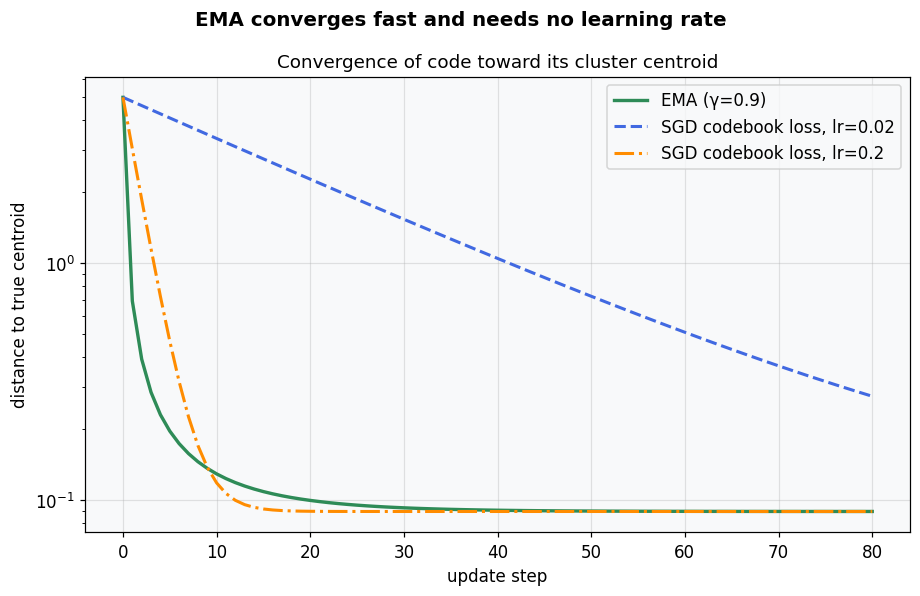

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
fig.suptitle('EMA converges fast and needs no learning rate', fontsize=13, fontweight='bold')

ax.plot(to_c(ema), color='seagreen', lw=2.2, label='EMA (γ=0.9)')
ax.plot(to_c(sgd_slow), color='royalblue', lw=2, ls='--', label='SGD codebook loss, lr=0.02')
ax.plot(to_c(sgd_fast), color='darkorange', lw=2, ls='-.', label='SGD codebook loss, lr=0.2')
ax.set_xlabel('update step'); ax.set_ylabel('distance to true centroid')
ax.set_yscale('log')
ax.set_title('Convergence of code toward its cluster centroid')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** All three reach the centroid, but the SGD curves' speed depends entirely on the learning rate — lr=0.02 (blue) crawls, lr=0.2 (orange) is much faster. EMA (green) converges quickly with no lr chosen at all.
2. **Why it looks this way:** EMA jumps the code straight toward the running mean of the assigned points, so its rate is set by γ alone and not by any gradient step size. SGD inches toward the same mean in steps proportional to lr, so a poorly chosen lr is slow (or, if too big, unstable).
3. **Key takeaway:** EMA removes one hyperparameter coupling — the codebook no longer shares the encoder/decoder's optimizer or lr, which is exactly why it trains more robustly.

---
## Experiment 3: Decay rate γ

**Question:** γ sets the EMA's memory window (~$1/(1-\gamma)$ batches). What is the cost of choosing it too low or too high?

We track a drifting centre with three γ values and watch the code path. Low γ should be fast but jittery; high γ should be smooth but lag behind the moving target.

In [6]:
np.random.seed(3)

T = 160
centre = np.stack([np.linspace(-2, 2, T), np.zeros(T)], axis=1)
gammas = [0.8, 0.95, 0.995]
paths = {}
for g in gammas:
    N_k, m_k = 1.0, np.array([-2.0, 0.0])
    p = []
    for t in range(T):
        batch = centre[t] + 0.5 * np.random.randn(16, 2)
        N_k = g * N_k + (1 - g) * len(batch)
        m_k = g * m_k + (1 - g) * batch.sum(0)
        p.append(m_k / N_k)
    paths[g] = np.array(p)
print('window ~ 1/(1-gamma):', {g: round(1 / (1 - g)) for g in gammas})

window ~ 1/(1-gamma): {0.8: 5, 0.95: 20, 0.995: 200}


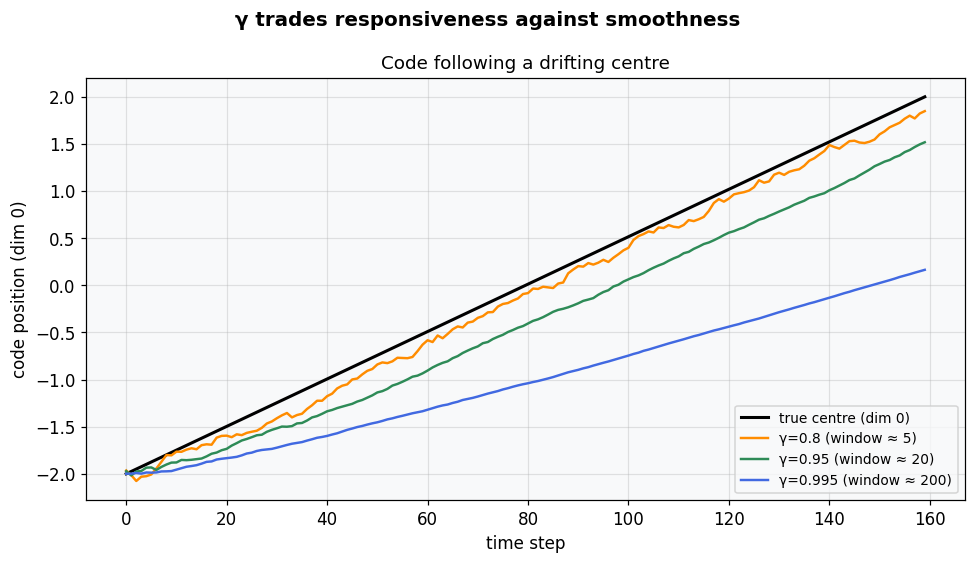

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.suptitle('γ trades responsiveness against smoothness', fontsize=13, fontweight='bold')

ax.plot(centre[:, 0], color='black', lw=2, label='true centre (dim 0)')
colors = ['darkorange', 'seagreen', 'royalblue']
for g, c in zip(gammas, colors):
    ax.plot(paths[g][:, 0], color=c, lw=1.6, label=f'γ={g} (window ≈ {round(1/(1-g))})')
ax.set_xlabel('time step'); ax.set_ylabel('code position (dim 0)')
ax.set_title('Code following a drifting centre')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** γ=0.8 (orange) hugs the true centre closely but is visibly jittery; γ=0.995 (blue) is glass-smooth but lags well behind the rising black line; γ=0.95 (green) sits in between.
2. **Why it looks this way:** A small γ averages over few batches, so it reacts fast but inherits batch noise. A large γ averages over many batches, smoothing noise away but responding slowly — hence the lag against a moving target.
3. **Key takeaway:** γ≈0.99 is the usual compromise: smooth enough to be stable, responsive enough to keep up. Too high and the codebook chronically trails a shifting encoder, feeding codebook collapse.

---
## Experiment 4: Laplace smoothing

**Question:** What happens to a code that is never selected, and why is Laplace smoothing needed in the $e_k = m_k/N_k$ division?

We run EMA over a codebook where one code is never the nearest neighbour. Its $N_k$ decays toward zero; the raw division becomes $0/0$. Laplace smoothing floors $N_k$ to a small positive value and keeps the code finite (parked at its init).

In [8]:
np.random.seed(4)

K, D = 4, 2
codebook = np.array([[0.0, 0.0], [1.0, 1.0], [5.0, 5.0], [-1.0, 1.0]])  # code 2 is far from data
N = np.ones(K)
M = codebook.copy().astype(float)
gamma, eps, steps = 0.9, 1e-5, 40

data_centre = np.array([0.3, 0.3])   # data lives near codes 0,1,3 only
N_hist = []
for _ in range(steps):
    batch = data_centre + 0.4 * np.random.randn(50, 2)
    d2 = ((batch[:, None, :] - codebook[None, :, :]) ** 2).sum(-1)
    assign = d2.argmin(1)
    counts = np.bincount(assign, minlength=K)
    sums = np.zeros((K, D))
    for k in range(K):
        if counts[k] > 0:
            sums[k] = batch[assign == k].sum(0)
    N = gamma * N + (1 - gamma) * counts
    M = gamma * M + (1 - gamma) * sums
    N_hist.append(N.copy())
N_hist = np.array(N_hist)

# raw vs Laplace-smoothed division for the dead code (#2)
n_total = N.sum()
N_smooth = (N + eps) / (n_total + K * eps) * n_total
raw_code2 = M[2] / N[2] if N[2] != 0 else np.array([np.nan, np.nan])
smooth_code2 = M[2] / N_smooth[2]
print(f'dead code #2 final N_k = {N[2]:.2e}')
print(f'raw    e_2 = {raw_code2}')
print(f'smooth e_2 = {smooth_code2.round(4)}  (stays at its init [5,5])')

dead code #2 final N_k = 1.48e-02
raw    e_2 = [5. 5.]
smooth e_2 = [4.9966 4.9966]  (stays at its init [5,5])


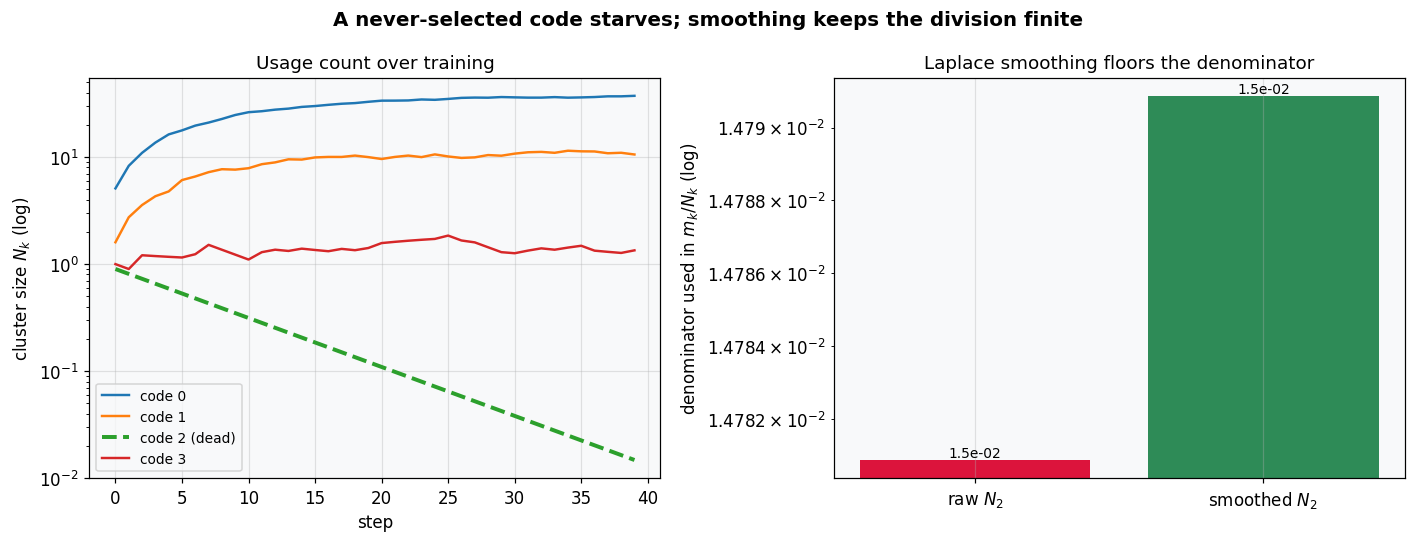

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('A never-selected code starves; smoothing keeps the division finite', fontsize=13, fontweight='bold')

ax = axes[0]
for k in range(K):
    style = '-' if k != 2 else '--'
    lw = 1.6 if k != 2 else 2.6
    ax.plot(N_hist[:, k], style, lw=lw, label=f'code {k}' + (' (dead)' if k == 2 else ''))
ax.set_yscale('log')
ax.set_xlabel('step'); ax.set_ylabel('cluster size $N_k$ (log)')
ax.set_title('Usage count over training')
ax.legend(fontsize=9)

ax2 = axes[1]
labels = ['raw $N_2$', 'smoothed $N_2$']
vals = [max(N[2], 1e-12), N_smooth[2]]
bars = ax2.bar(labels, vals, color=['crimson', 'seagreen'])
ax2.set_yscale('log')
ax2.set_ylabel('denominator used in $m_k/N_k$ (log)')
ax2.set_title('Laplace smoothing floors the denominator')
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v, f'{v:.1e}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Codes 0, 1, 3 keep healthy usage counts; the dashed dead code 2 decays geometrically toward zero (left). The right bars contrast the raw denominator (vanishingly small, crimson) with the Laplace-smoothed one (a small positive floor, green); the printout shows the smoothed code stays finite at its init while the raw division heads toward $0/0$.
2. **Why it looks this way:** With no assignments, both $N_k$ and $m_k$ are multiplied by γ every step, decaying toward zero, so $m_k/N_k$ becomes numerically unstable. Laplace smoothing adds $\varepsilon$ to the count and renormalises, guaranteeing a strictly positive denominator.
3. **Key takeaway:** Smoothing is a numerical safeguard, not a fix for the underlying problem — code 2 is still dead. Reviving dead codes needs explicit restarts, the subject of the next topic.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Online k-means | $e_k = m_k/N_k$ tracks the running centroid of its assigned points — EMA *is* incremental k-means. |
| 2. EMA vs gradient | EMA converges fast with no learning rate to tune, decoupling the codebook from the encoder/decoder optimizer. |
| 3. Decay rate γ | Low γ is responsive but jittery; high γ is smooth but lags; ≈0.99 is the usual balance. |
| 4. Laplace smoothing | A never-selected code's denominator decays to zero; smoothing floors it, but the code is still dead. |

### Connection to the broader theory

EMA stabilises the codebook side of vector quantization, just as [commitment loss](../research/02-commitment-loss.md) stabilises the encoder side. But Experiment 4 exposes the limit both share: neither can revive a code that the `argmin` never picks. That failure mode — most of the codebook going unused — is **codebook collapse**, the next topic, along with the restart tricks that bring dead codes back to life.